# Landsat images

Peter Ralph  
2026-03-02

# Data: Landsat images

## 

> The [NASA/USGS Landsat
> program](https://science.nasa.gov/mission/landsat/) provides the
> longest continuous space-based record of Earth’s land in existence.
> Landsat data are essential for making informed decisions about our
> planet’s resources and environment.

<figure>
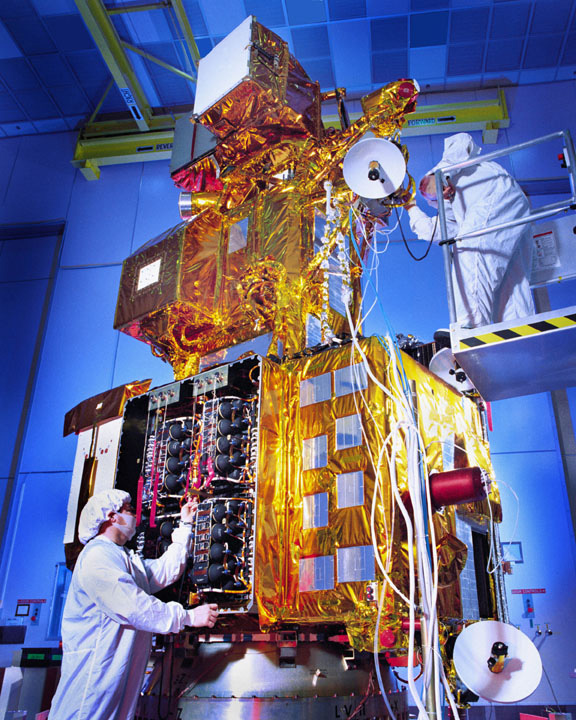
<figcaption aria-hidden="true">picture of a landsat sattelite from NASA
via Wikimedia Commons</figcaption>
</figure>

## 

Data (Landsat 8/9):

-   700 scenes/day, 185km wide
-   11 spectral bands from a [multispectral
    scanner](https://en.wikipedia.org/wiki/Multispectral_Scanner)
-   15m/30m/100m pixels

<figure>
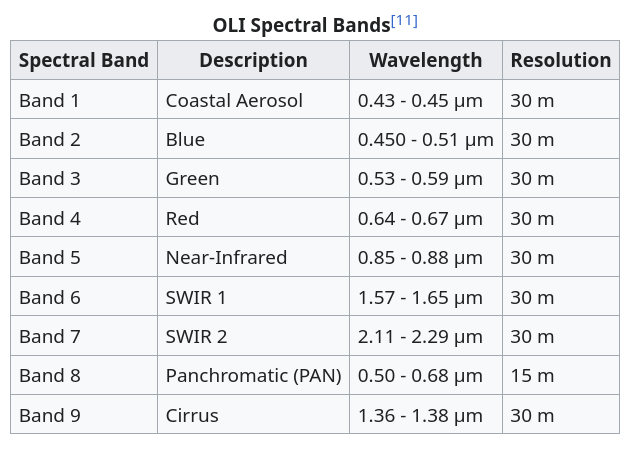
<figcaption aria-hidden="true">table of bands from <a
href="https://en.wikipedia.org/wiki/Landsat_8">Wikipedia</a></figcaption>
</figure>

<figure>
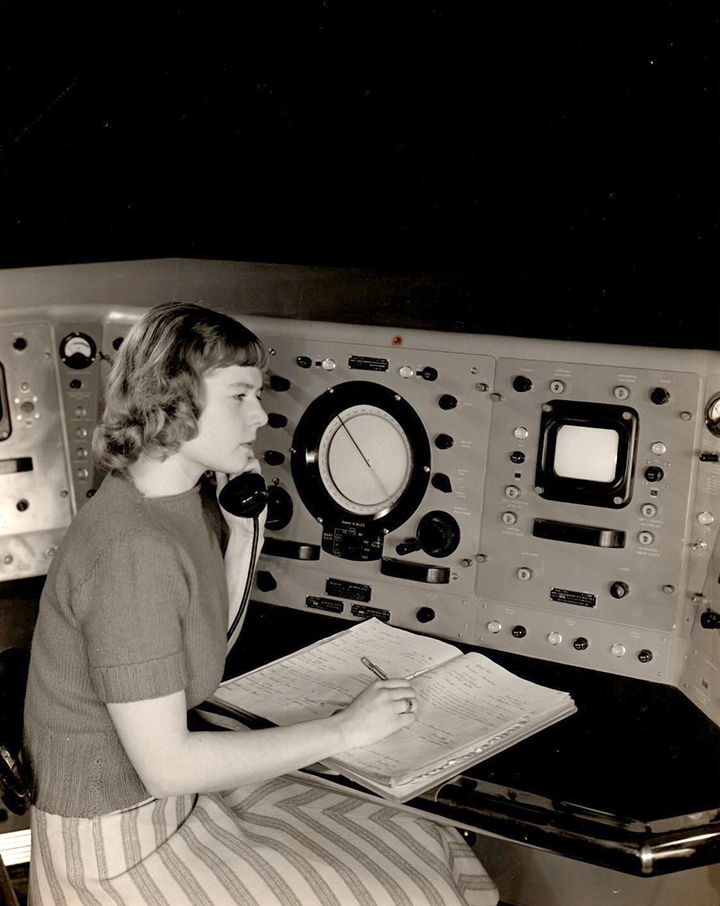
<figcaption aria-hidden="true">photo of Virginia Norwood from
https://landsat.gsfc.nasa.gov/article/virginia-t-norwood-mother-landsat</figcaption>
</figure>

[Virginia Norwood](https://en.wikipedia.org/wiki/Virginia_T._Norwood)

## Obtaining the data

It’s free: from
[earthexplorer.usgs.gov](https://earthexplorer.usgs.gov/)

as
[GeoTIFF](https://blogs.loc.gov/maps/2023/05/the-secret-life-of-geotiffs/)
raster files

and there’s a LOT of it: each scene is ~1G

``` sh
$ ls -lath *.tar
-rw-rw-r-- 1 peter peter 948M Mar  1 08:33 LC08_L2SP_046029_20250602_20250607_02_T1.tar
-rw-rw-r-- 1 peter peter 962M Mar  1 08:29 LC08_L2SP_046029_20200604_20200825_02_T1.tar
```

<figure>
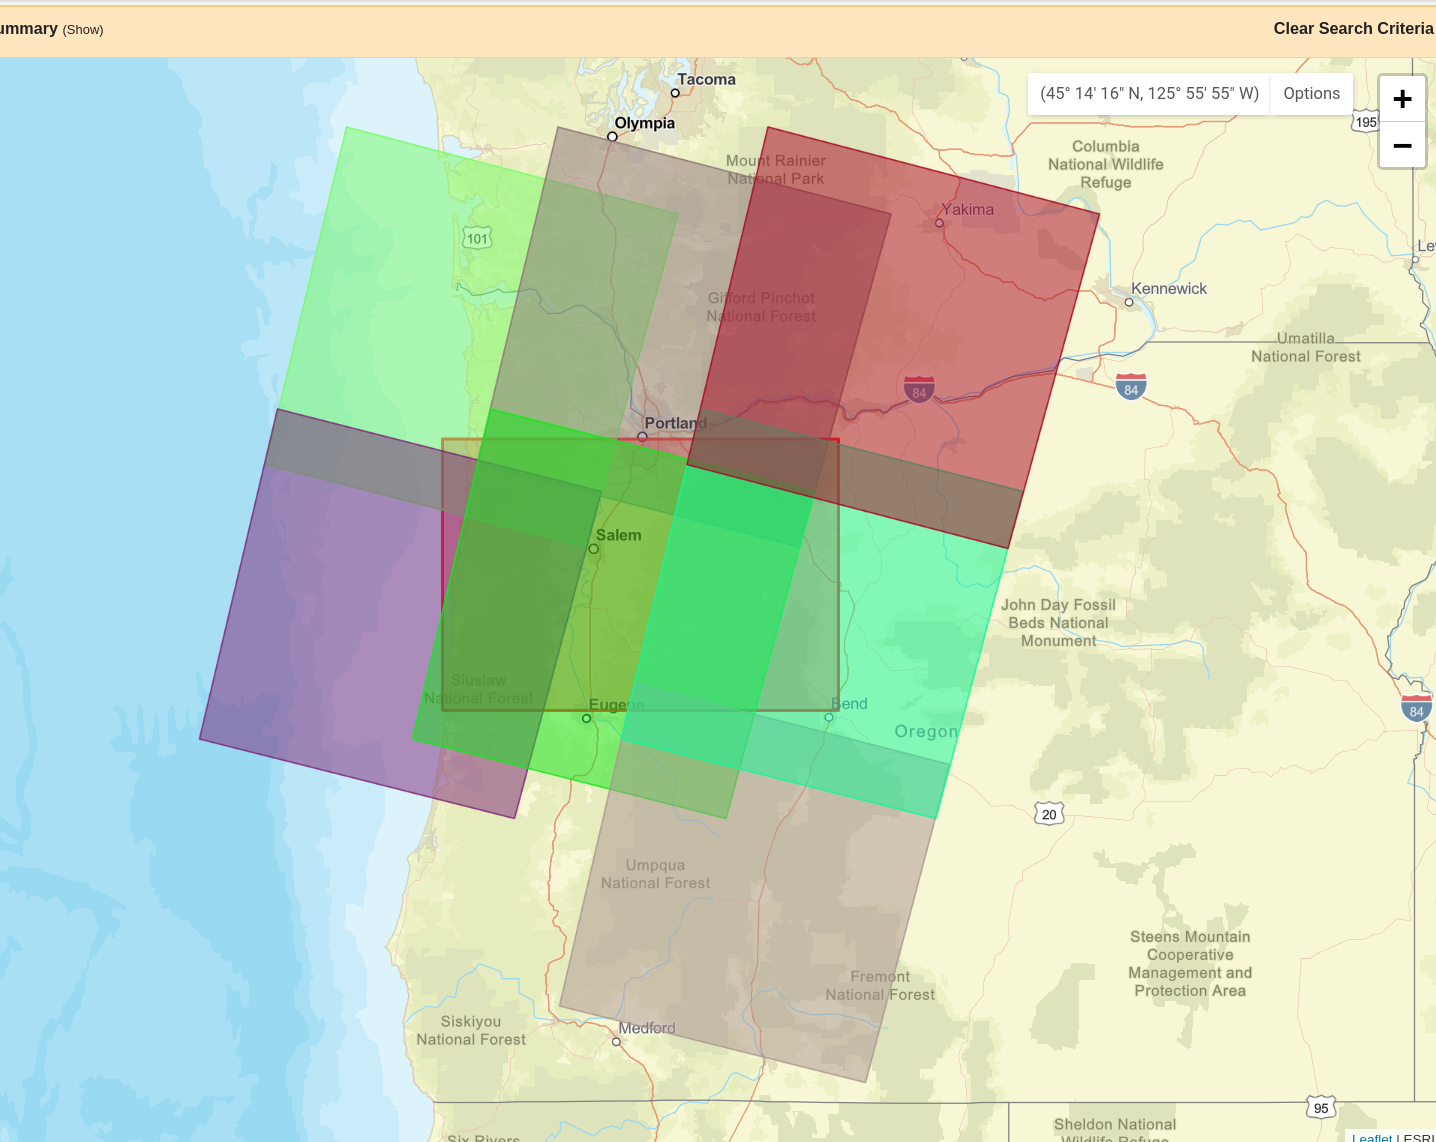
<figcaption aria-hidden="true">screenshot of map from
earthexplorer</figcaption>
</figure>

# Raster data in python

Some good references:

-   the [rasterio
    docs](https://rasterio.readthedocs.io/en/stable/quickstart.html)
-   [geocomputation with
    python](https://py.geocompx.org/02-attribute-operations#sec-manipulating-raster-objects)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pyproj
import contextily
import json
import matplotlib.pyplot as plt
import shapely
import rasterio
import rasterio.plot
import rasterio.mask

## Files

I’ve picked a day without a lot of clouds (Aug 25, 2020), downloaded the
data above Eugene, unpackaged the tar archive and put the basic bands,
cropped somewhat for file size, in [data/landsat](../data/landsat):

-   [Metadata file for
    bands](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_MTL.json)
-   [Band
    1](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B1.TIF)
-   [Band
    2](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B2.TIF)
-   [Band
    3](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B3.TIF)
-   [Band
    4](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B4.TIF)
-   [Band
    5](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B5.TIF)
-   [Band
    6](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B6.TIF)
-   [Band
    7](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B7.TIF)
-   [thumbnail,
    large](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_thumb_large.jpeg)
-   [thumbnail,
    small](../data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_thumb_small.jpeg)

## Metadata

You’ll need to get the data, linked on the previous slide or from
[github](https://github.com/UOdsci/ds435/tree/main/data/landsat), and
put it in the `data/landsat/` subdirectory.

This comes with a JSON metadata file:

In [2]:
ddir = "data/landsat"
fname = "LC08_L2SP_046029_20200604_20200825_02_T1"
with open(f"{ddir}/{fname}_MTL.json", "r") as f:
    md = json.loads(f.read())

list(md['LANDSAT_METADATA_FILE'].keys())

['PRODUCT_CONTENTS',
 'IMAGE_ATTRIBUTES',
 'PROJECTION_ATTRIBUTES',
 'LEVEL2_PROCESSING_RECORD',
 'LEVEL2_SURFACE_REFLECTANCE_PARAMETERS',
 'LEVEL2_SURFACE_TEMPERATURE_PARAMETERS',
 'LEVEL1_PROCESSING_RECORD',
 'LEVEL1_MIN_MAX_RADIANCE',
 'LEVEL1_MIN_MAX_REFLECTANCE',
 'LEVEL1_MIN_MAX_PIXEL_VALUE',
 'LEVEL1_RADIOMETRIC_RESCALING',
 'LEVEL1_THERMAL_CONSTANTS',
 'LEVEL1_PROJECTION_PARAMETERS']

## Of note: file names

In [3]:
md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']

{'ORIGIN': 'Image courtesy of the U.S. Geological Survey',
 'DIGITAL_OBJECT_IDENTIFIER': 'https://doi.org/10.5066/P9OGBGM6',
 'LANDSAT_PRODUCT_ID': 'LC08_L2SP_046029_20200604_20200825_02_T1',
 'PROCESSING_LEVEL': 'L2SP',
 'COLLECTION_NUMBER': '02',
 'COLLECTION_CATEGORY': 'T1',
 'OUTPUT_FORMAT': 'GEOTIFF',
 'FILE_NAME_BAND_1': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B1.TIF',
 'FILE_NAME_BAND_2': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B2.TIF',
 'FILE_NAME_BAND_3': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B3.TIF',
 'FILE_NAME_BAND_4': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B4.TIF',
 'FILE_NAME_BAND_5': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B5.TIF',
 'FILE_NAME_BAND_6': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B6.TIF',
 'FILE_NAME_BAND_7': 'LC08_L2SP_046029_20200604_20200825_02_T1_SR_B7.TIF',
 'FILE_NAME_BAND_ST_B10': 'LC08_L2SP_046029_20200604_20200825_02_T1_ST_B10.TIF',
 'FILE_NAME_THERMAL_RADIANCE': 'LC08_L2SP_046029_20200604_20200825_02_T1_ST_TRAD.TIF',

## Opening a raster:

In [4]:
band5 = rasterio.open(ddir + "/" + md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']['FILE_NAME_BAND_5'])
band5.shape

(2635, 7801)

In [5]:
band5.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0.0,
 'width': 7801,
 'height': 2635,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'),
 'transform': Affine(30.0, 0.0, 393885.0,
        0.0, -30.0, 4938915.0)}

## Viewing the raster:

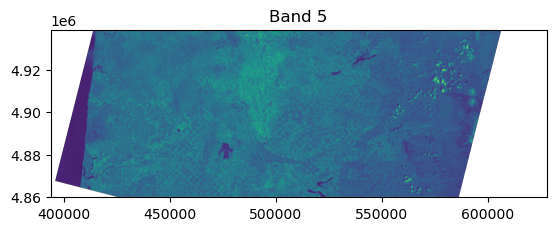

In [6]:
fig, ax = plt.subplots()
rasterio.plot.show(band5, ax=ax)
ax.set_title("Band 5");

## Viewing the raster, in context:

Note the `crs`!

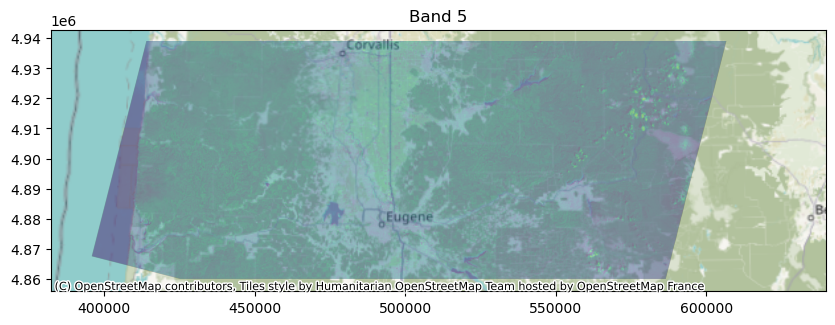

In [7]:
bbox = gpd.GeoSeries(shapely.geometry.box(*band5.bounds), crs=band5.crs)

fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=band5.crs)
rasterio.plot.show(band5, ax=ax, alpha=0.5)
ax.set_title("Band 5");

## Values:

`raster.read()` gets a numpy array of the values. Note the *missing
data*:

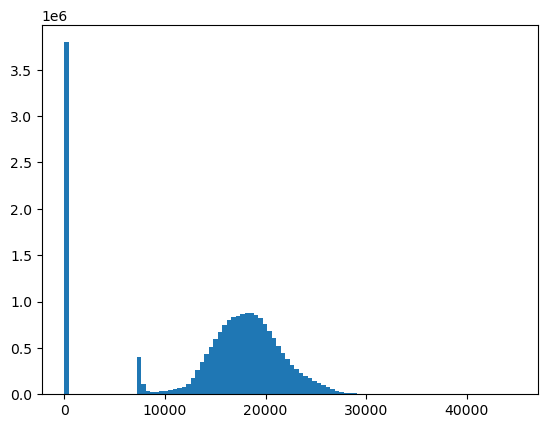

In [8]:
plt.hist(
    band5.read().flatten(),
    bins=100,
);

# Now, let’s explore!

*Things we won’t talk about:* (see [the
docs](resources/LSDS-1619_Landsat8-9-Collection2-Level2-Science-Product-Guide-v6.pdf)
for a lot more!)

-   USGS provides lots of downstream data products! Sophisticated
    combinations of bands to help:

    -   ignore clouds
    -   get useful real-world measurements (snow cover, thermal
        upwelling…)

-   What the spectral bands “mean”

-   How these bands relate to what we see

-   What people usually use this data for

## Goals:

Basically, “make a nice picture”.

Concretely: make a map where color communicates something important
about land type.

Two possible workflows:

1.  Pick a few ‘different’ locations on the map; find some combinations
    of bands that distinguish those; map these to colors.

2.  Do PCA, and map the PCs to colors.

## A quick reminder about “colorspace”:

-   Human retinas most commonly have three kinds of color-sensitive
    photoreceptors.
-   So, our color perception is “three-dimensional”.
-   Printing: RGB (e.g.,
    \#<span style="color: red;">3A</span><span style="color: green;">11</span><span style="color: blue;">FF</span>;)
    or CMYK
-   Perception: [HSL and HSV](https://en.wikipedia.org/wiki/HSL_and_HSV)
-   **Plus:** transparancy, or `alpha`:
    \#<span style="color: #FF0000FF;">3A</span><span style="color: #00FF00FF;">11</span><span style="color: #0000FFFF;">FF</span><span style="color: #00000088;">00</span>;
-   On computer monitors, RGB values range from 0 to 255.

So, by “make an image” we mean “make 1 to 3 rectangular arrays of
integers between 0 and 255”.

<figure>
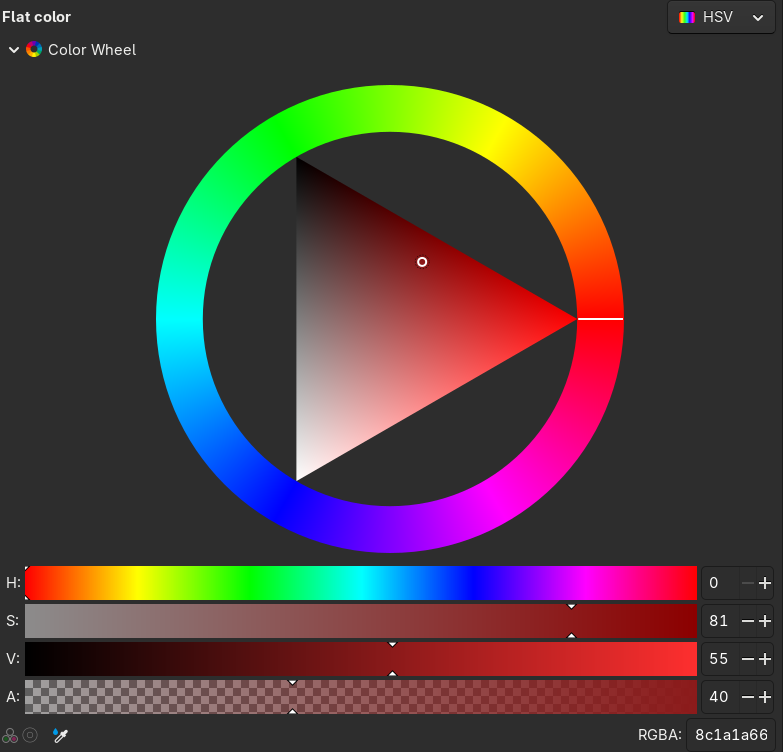
<figcaption aria-hidden="true">screenshot of a color picker in HSV
space</figcaption>
</figure>

## Brainstorming:

1.  Pick a few ‘different’ locations on the map; find some combinations
    of bands that distinguish those; map these to colors.

2.  Do PCA, and map the PCs to colors.

-   What is the difference between these?
-   How would we actually do (1)?
-   How would we actually do (2)?

# Tools

We could just reduce the landsat images to arrays, but we’d like to
maintain spatial context.

So, we’ll need to:

-   Extract values from all the bands at particular locations.
-   Extract values from all the bands averaged across polygons (e.g., a
    circle around a location).
-   Combine together bands arithmetically.
-   Turn the result into an image.

## Get the bands in order:

*Note:* beware; trying to do some things with all of these (e.g., plot
them all) might crash your browser.

In [9]:
band_names = [f"BAND_{k}" for k in range(1,7)]
file_names = {
    bn : ddir + "/" + md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']["FILE_NAME_" + bn]
    for bn in band_names
}
bands = { bn: rasterio.open(file_names[bn]) for bn in band_names }

# Working with layers

First let’s look at mapping values to images, and rescaling.

## Low contrast?

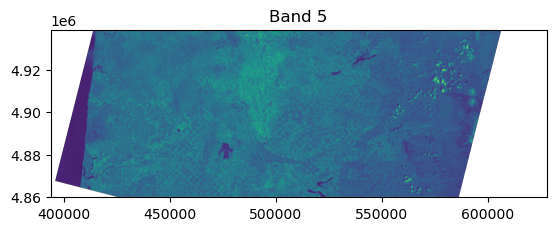

In [10]:
fig, ax = plt.subplots()
rasterio.plot.show(band5, ax=ax)
ax.set_title("Band 5");

## Well, that makes sense:

data: (2635, 7801) mask: (2635, 7801)


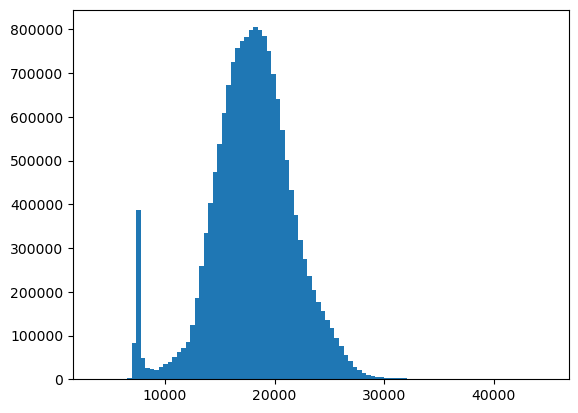

In [11]:
values = band5.read(masked=True).squeeze()
print('data:', values.data.shape, 'mask:', values.mask.shape)
plt.hist(values.data[~values.mask], bins=100);

## Let’s rescale!

And, let’s work with just numpy arrays for a bit.

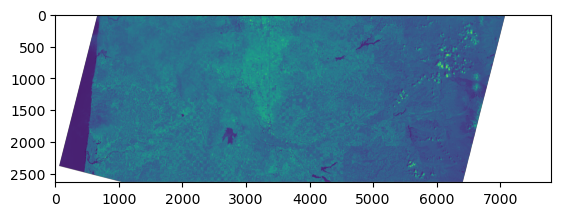

In [12]:
plt.imshow(values)

## Rescaling:

And, let’s work with just numpy arrays for a bit.

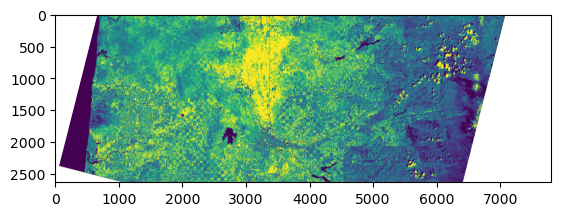

In [13]:
a, b = np.quantile(values.data[~values.mask], q=[0.05, 0.95])
values = (values - a) / (b - a)
values = np.minimum(1.0, np.maximum(0.0, values))
values = (255 * values).astype(int)
plt.imshow(values)

## How about in color?

values: (2635, 7801, 3)


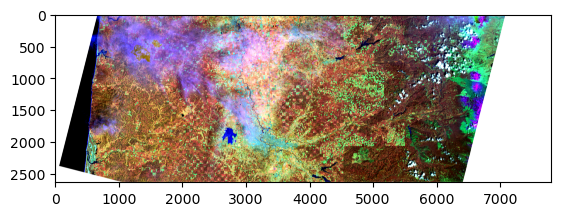

In [18]:
def norm_values(bn):
    values = bands[bn].read(masked=True)
    a, b = np.quantile(values.data[~values.mask], q=[0.05, 0.95])
    values = 255*(values - a)/(b - a)
    values[values<0] = 0
    values[values>255] = 255
    return values.astype(int)
    
values = np.ma.array([norm_values(bn) for bn in ["BAND_5", "BAND_6", "BAND_3"]]).squeeze()
values = np.moveaxis(values, [0, 1, 2], [2, 0, 1])
print('values:', values.shape)
plt.imshow(values);

## Putting this back on a map:

All it takes is the right `transform` argument!

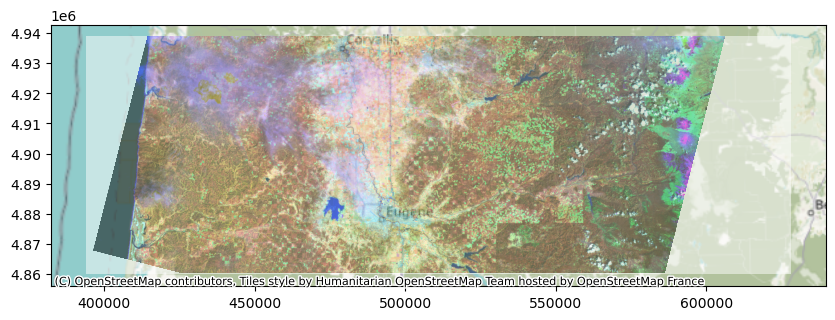

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=bands["BAND_5"].crs)
rasterio.plot.show(np.moveaxis(values, [0,1,2], [1,2,0]), transform=bands["BAND_5"].transform, ax=ax, alpha=0.5);

## Or, with `ax.imshow`:

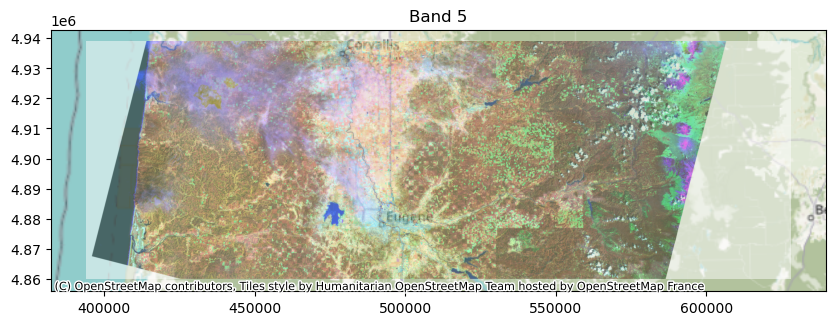

In [20]:
fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=bands["BAND_5"].crs)
ax.imshow(values, extent=bbox.bounds[['minx', 'maxx', 'miny', 'maxy']].values[0], alpha=0.5);
ax.set_title("Band 5");

# Extracting values

We’ll do this “by hand”; another method would use
[rasterstats](https://pythonhosted.org/rasterstats/).

First: pick some points:

In [21]:
npts = 10
pts = bbox.sample_points(npts, seed=123)
pd.concat([pts, bbox]).explore()

/tmp/ipykernel_379691/352313147.py:2: FutureWarning: The 'seed' keyword is deprecated. Use 'rng' instead.
  pts = bbox.sample_points(npts, seed=123)


## Pour one out for the NAs

Some of the points will be outside the area of the raster:

In [22]:
bn = 'BAND_5'
xyz = pts.get_coordinates()
xyz[bn] = np.array(list(bands[bn].sample([xy[1:] for xy in xyz.itertuples()]))).flatten()
xyz

,x,y,BAND_5
0,406480.733030,4.879229e+06,7540
0,435052.258031,4.918478e+06,19706
0,437033.534858,4.876763e+06,15259
0,445455.821025,4.925021e+06,18754
0,458611.706316,4.878197e+06,20870
0,553575.806556,4.900415e+06,14375
0,583939.477393,4.909662e+06,13602
0,585732.160050,4.923036e+06,15186
0,602146.586969,4.900826e+06,0
0,609975.429888,4.933177e+06,0


## Rejection sampling:

Let’s sample more than we need and restrict to ones coved by the data:

In [27]:
pts = bbox.sample_points(2*npts, seed=123).explode(index_parts=True)[0]
xyz = pts.get_coordinates()
xyz[bn] = np.array(list(bands[bn].sample([xy[1:] for xy in xyz.itertuples()]))).flatten()
pts = pts.loc[xyz[bn] > 0][:npts]
pd.concat([pts, bbox]).explore()

/tmp/ipykernel_379691/1854403256.py:1: FutureWarning: The 'seed' keyword is deprecated. Use 'rng' instead.
  pts = bbox.sample_points(2*npts, seed=123).explode(index_parts=True)[0]


## Extracting values from circles

A single pixel seems kinda… noisy? Let’s take averages within some
buffer around each point.

In [28]:
pts = pts.buffer(5000)
pd.concat([pts, bbox]).explore()

## 

Of use: `mask`

shape: {im.shape}


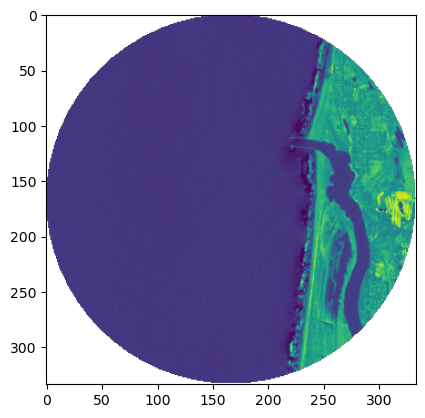

In [25]:
im, mask = rasterio.mask.mask(
    bands['BAND_5'], 
    [pts.iloc[0]],
    crop=True,
    filled=False,
)
print("shape: {im.shape}")
plt.imshow(im.squeeze());

## Let’s get some tooling together:

1.  Write a fuction that gets average values in each of a bunch of
    polygons from a band.
2.  Apply that function to each of our bands.

In [38]:
def zonal_means(pts, band):
    """
    `band` is the name of a band
    `pts` is a GeoDataSeries of polygons
    """
    out = np.empty((len(pts),))
    for i, polygon in enumerate(pts):
        im, mask = rasterio.mask.mask(
            bands[band], 
            [polygon],
            crop=True,
            filled=False
        )
        out[i] = im.mean()
    return out

zonal_means(pts, 'BAND_1')

array([7630.71123533, 8044.02707386, 8328.24832723, 8408.99120834,
       8082.76198455, 8544.87673324, 8535.13197067, 8311.61063735,
       7916.64888098, 7850.88506565])

In [61]:
rng = np.random.default_rng()
npts = 1000
pts = bbox.sample_points(2*npts, seed=123).explode(index_parts=True)[0]
xyz = pts.get_coordinates()
xyz['BAND_1'] = np.array(list(bands['BAND_1'].sample([xy[1:] for xy in xyz.itertuples()]))).flatten()
pts = pts.loc[xyz['BAND_1'] > 0]
use_these = rng.choice(pts.index, size=npts)
pts = pts[use_these].buffer(1000)
pd.concat([pts, bbox]).explore()

/tmp/ipykernel_379691/3466197770.py:3: FutureWarning: The 'seed' keyword is deprecated. Use 'rng' instead.
  pts = bbox.sample_points(2*npts, seed=123).explode(index_parts=True)[0]


In [62]:
point_data = gpd.GeoDataFrame(pts)
for b in bands:
    point_data[b] = zonal_means(pts, b)

In [63]:
point_data

,0,BAND_1,BAND_2,BAND_3,BAND_4,BAND_5,BAND_6
1241,"POLYGON ((536309.936 4906381.214, 536305.121 4...",8046.910109,8254.943998,9376.990810,8982.955773,18181.083573,13702.074095
1667,"POLYGON ((588858.506 4877007.278, 588853.691 4...",7348.493831,7629.196557,8308.968723,8176.907604,13010.095552,9845.050789
887,"POLYGON ((497042.288 4930316.588, 497037.473 4...",7927.743759,8366.024390,9952.805452,9146.419799,24390.684935,12280.971306
129,"POLYGON ((411513.25 4899398.473, 411508.435 48...",7687.950100,8054.892458,8619.701463,8063.664468,9242.236020,8319.977344
510,"POLYGON ((454897.822 4892049.064, 454893.006 4...",8039.821808,8157.076614,9127.157532,8428.369010,19901.292109,12197.892970
...,...,...,...,...,...,...,...
408,"POLYGON ((444223.016 4930618.966, 444218.2 493...",8140.159794,8716.196449,10108.841065,9653.611111,17973.542383,11428.232818
405,"POLYGON ((443963.13 4912466.339, 443958.315 49...",8324.957856,8963.727064,10643.980505,10028.122133,20059.168005,11926.075115
1036,"POLYGON ((513273.488 4897853.815, 513268.673 4...",7697.476327,7842.734003,8758.615208,8111.825538,17128.527403,10766.149498
1336,"POLYGON ((547629.313 4913842.395, 547624.497 4...",7924.341365,8023.685600,8928.323867,8277.307516,18032.015777,10987.135112


In [65]:
point_data.select_dtypes("float").values

array([[ 8046.91010913,  8254.9439977 ,  9376.99080988,  8982.95577254,
        18181.08357266, 13702.07409535],
       [ 7348.4938307 ,  7629.19655667,  8308.9687231 ,  8176.90760402,
        13010.09555237,  9845.0507891 ],
       [ 7927.74375897,  8366.02439024,  9952.80545194,  9146.41979914,
        24390.68493544, 12280.9713056 ],
       ...,
       [ 7697.47632712,  7842.73400287,  8758.61520803,  8111.82553802,
        17128.52740316, 10766.14949785],
       [ 7924.34136546,  8023.68559954,  8928.3238669 ,  8277.30751578,
        18032.0157774 , 10987.13511188],
       [ 8008.00057488,  8202.79160678,  9252.87007761,  8838.97987928,
        18424.99367634, 13021.27795343]], shape=(1000, 6))